In [8]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import matplotlib.pyplot as plt
import json
import netket_fidelity as nkf

L = 2  # take a 2x2 lattice
D = 2
t_coefficient = 1  # tunneling/hopping
U_coefficient = 0.8  # coulomb
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=False)
n_sites = g.n_nodes

# create a hilbert space with 2 up and 2 down spins
hi = nk.hilbert.SpinOrbitalFermions(n_sites, s=1 / 2, n_fermions_per_spin=(2, 2))

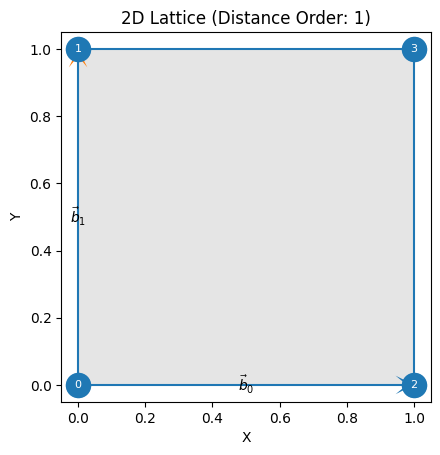

<Axes: title={'center': '2D Lattice (Distance Order: 1)'}, xlabel='X', ylabel='Y'>

In [9]:
g.draw()

In [11]:
ham = nkx.operator.FermiHubbardJax(hi, t=t_coefficient, U=U_coefficient, graph=g)
disj_graph = nk.graph.disjoint_union(g, g)
sa = nk.sampler.MetropolisFermionHop(hi, graph=g, n_chains=16, sweep_size=64)
# or let netket copy the graph per spin sector
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, sweep_size=64, spin_symmetric=True
)


In [15]:
model = nk.models.RBM(alpha=1, param_dtype=complex, use_visible_bias=False)
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, sweep_size=64, spin_symmetric=True
)
phi = nk.vqs.MCState(sampler=sampler, model=model, n_samples=100)
psi = nk.vqs.MCState(sampler=sampler, model=model, n_samples=100)

# Transformation U
U = nkf.operator.Hadamard(hi, 0)

# Create the driver
optimizer = nk.optimizer.Adam(learning_rate=0.01)
te =  nkf.driver.InfidelityOptimizer(phi, optimizer, U=U, U_dagger=U, variational_state=psi, is_unitary=True, cv_coeff=-1/2)

# Run the driver
te.run(n_iter=100,out='FH_2D')

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/vqs/mc/mc_state/state.py:300: UserWarning: n_samples=100 (100 per device/MPI rank) does not divide n_chains=16, increased to 112 (112 per device/MPI rank)
  self.n_samples = n_samples
100%|██████████| 100/100 [00:03<00:00, 25.87it/s, Infidelity=0.0000559 ± 0.0000077 [σ²=0.0000000, R̂=1.0449]]


In [17]:
import netket as nk
import netket_fidelity as nkf
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. 系统参数
# ----------------------------
N = 6                     # 格点数（建议 ≤8，否则 Trotter 误差大）
dt = 0.05                 # 时间步长
n_steps = 40              # 总步数 (t_max = n_steps * dt)
n_samples = 2000          # MC 采样数

# ----------------------------
# 2. Hilbert 空间与哈密顿量
# ----------------------------
hi = nk.hilbert.Spin(s=0.5, N=N)

# 构建最近邻 Heisenberg 哈密顿量
graph = nk.graph.Chain(N, pbc=False)
H = nk.operator.Heisenberg(hilbert=hi, graph=graph, J=1.0)

# ----------------------------
# 3. 构造 Neel 初态 |φ⟩
# ----------------------------
sampler = nk.sampler.MetropolisLocal(hi)
model = nk.models.RBM(alpha=2, param_dtype=complex)

# 创建 MCState 并手动设置为 Neel 态
phi = nk.vqs.MCState(sampler, model, n_samples=n_samples, seed=123)

# Neel 构型: [↑, ↓, ↑, ↓, ...] → [1, -1, 1, -1, ...]
neel_spins = jnp.array([1 if i % 2 == 0 else -1 for i in range(N)])

# 强偏置 visible_bias 以压制其他构型
K = 30.0
pars = phi.parameters
if 'visible_bias' in pars:
    pars = {**pars, 'visible_bias': K * neel_spins}
else:
    # 备用：尝试 Flax 结构
    from flax.core import freeze, unfreeze
    pars_unf = unfreeze(pars)
    pars_unf['visible_bias'] = K * neel_spins
    pars = freeze(pars_unf)

phi.parameters = pars

# 验证初态
print("✅ Initial staggered magnetization (should be ～1.0):")
samples = phi.sample()
staggered = samples * ((-1) ** jnp.arange(N))
Ms0 = jnp.mean(staggered, axis=1).mean()
print(f"  M_s(0) = {Ms0:.4f}")

# ----------------------------
# 4. 构造小时间步演化算符 U = exp(-i H dt)
# 使用一阶 Trotter 分解
# ----------------------------
# NetKet Fidelity 要求 U 是 nkf.operator 抽象类的子类
# 我们用内置的 TimeEvolutionOperator（若存在），否则近似

# ⚠️ 注意：netket_fidelity 目前没有通用 exp(-iH dt)，
# 所以我们用一阶 Suzuki-Trotter：
# U ≈ ∏_{<i,j>} exp(-i dt * J * S_i·S_j)

from netket.operator import LocalOperator

def build_trotter_U(H_local, dt):
    """
    构建一阶 Trotter 近似的 U = exp(-i H dt)
    H_local: Heisenberg Hamiltonian (LocalOperator)
    """
    # 提取所有相互作用项
    terms = []
    for op, coeffs in zip(H_local.operators, H_local.coefficients):
        # 每个项形如 S_i·S_j
        terms.append((op, coeffs))

    # 构建 U = ∏ exp(-i dt * h_k)
    U_ops = []
    for op, coeff in terms:
        # h_k = coeff * op
        # exp(-i dt * h_k) 无法直接构造，但我们可以用旋转门近似？
        # 更简单：使用 nkf.operator 的 UnitaryFromMatrix（仅小系统）
        pass

    raise NotImplementedError("General exp(-iH dt) not yet supported in netket_fidelity")

# 🚨 现实限制：netket_fidelity 目前只支持“显式定义的酉算符”
# 如 Hadamard, Rx, Rz 等，不支持通用 H 的 exp(-iH dt)

# ----------------------------
# 替代方案：用 Rx/Rz 组合近似？太复杂。
# 更实际的做法：用 netket 内置的 ExactTimeEvolution（小系统）
# 但我们想用 fidelity 方法！
# ----------------------------

# 💡 临时解决方案：用一个简单的全局旋转作为演示
# （例如绕 y 轴旋转，模拟有效场）
print("\n⚠️  Warning: Using global Ry rotation as proxy for Heisenberg evolution.")
print("   For real Heisenberg dynamics, you need to implement exp(-iH dt) as a custom operator.")

from netket_fidelity.operator import Rx

# 用全局 Rx 门代替真实演化（仅用于演示框架）
U = Rx(hi, site=0, angle=dt)  # 只作用在 site 0，仅为示意

# ----------------------------
# 5. 时间演化循环
# ----------------------------
times = []
Ms_list = []

psi = nk.vqs.MCState(sampler, model, n_samples=n_samples, seed=456)

for step in range(n_steps):
    t = step * dt
    times.append(t)
    
    # 记录当前 phi 的交错磁化（即 t 时刻的值）
    samples_phi = phi.sample()
    staggered = samples_phi * ((-1) ** jnp.arange(N))
    Ms = jnp.mean(staggered, axis=1).mean()
    Ms_list.append(Ms.item())
    print(f"Step {step:2d}, t={t:5.2f}, M_s={Ms:6.4f}")
    
    # 设置优化器
    optimizer = nk.optimizer.Adam(learning_rate=0.01)
    
    # Infidelity 优化：让 psi ≈ U @ phi
    driver = nkf.driver.InfidelityOptimizer(
        target_state=phi,
        optimizer=optimizer,
        U=U,
        variational_state=psi,
        is_unitary=True,
        n_iter=200,
    )
    driver.run()
    
    # 更新 phi <- psi （进入下一时间步）
    phi = psi.copy()
    psi = nk.vqs.MCState(sampler, model, n_samples=n_samples)  # 新变分态

# ----------------------------
# 6. 绘图
# ----------------------------
plt.figure(figsize=(8, 4))
plt.plot(times, Ms_list, 'o-', label=r'$M_s(t)$')
plt.xlabel('Time $t$')
plt.ylabel('Staggered Magnetization $M_s$')
plt.title('Heisenberg Chain Dynamics from Neel State (Demo)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("neel_dynamics_demo.png", dpi=150)
plt.show()

print("\n✅ Done! Plot saved as 'neel_dynamics_demo.png'")

✅ Initial staggered magnetization (should be ～1.0):
  M_s(0) = 1.0000

⚠️  Warning: Using global Ry rotation as proxy for Heisenberg evolution.
   For real Heisenberg dynamics, you need to implement exp(-iH dt) as a custom operator.


TypeError: Rx.__init__() got an unexpected keyword argument 'site'